<a href="https://colab.research.google.com/github/suhani242/T170800236_TNS_AIML/blob/main/AIML_day10__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Salary Dataset

Kaggle Dataset Link:

https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d abhishek14398/salary-dataset-simple-linear-regression

Dataset URL: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression
License(s): CC0-1.0
salary-dataset-simple-linear-regression.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
import os
import pandas as pd

with zipfile.ZipFile('salary-dataset-simple-linear-regression.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

csv_path = None
for root, dirs, files in os.walk('data'):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)

print("CSV found at:", csv_path)

df = pd.read_csv(csv_path)

print(df.head())
print(df.info())

CSV found at: data/Salary_dataset.csv
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


In [ ]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [ ]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

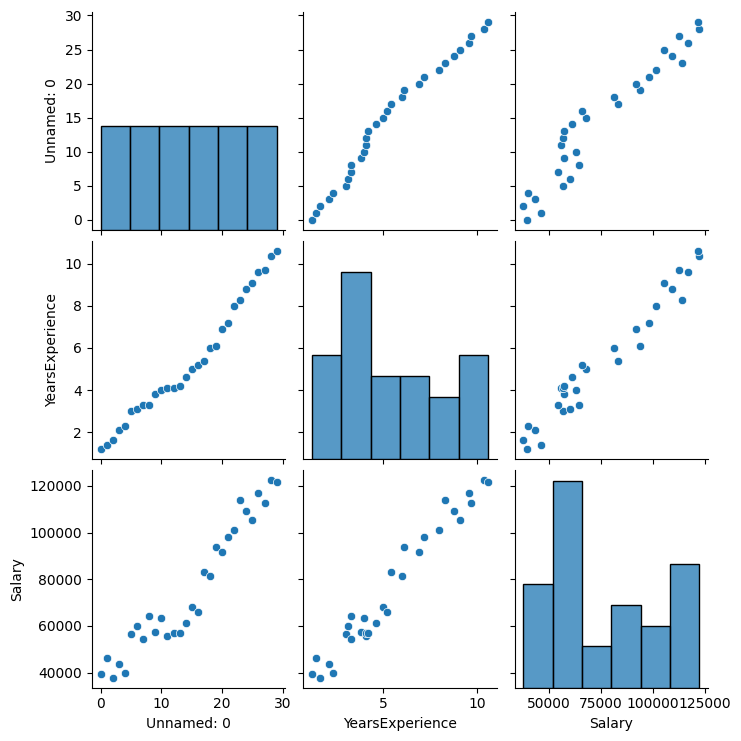

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
df['Experience_Squared'] = df['YearsExperience'] ** 2
df.head()

,Unnamed: 0,YearsExperience,Salary,Experience_Squared
0,0,1.2,39344.0,1.44
1,1,1.4,46206.0,1.96
2,2,1.6,37732.0,2.56
3,3,2.1,43526.0,4.41
4,4,2.3,39892.0,5.29


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import zipfile
import os
import pandas as pd

# Extract ZIP
with zipfile.ZipFile('salary-dataset-simple-linear-regression.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

# 🔍 Find CSV file automatically
csv_path = None
for root, dirs, files in os.walk('data'):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)

print("CSV found at:", csv_path)

# 📂 Load dataset
df = pd.read_csv(csv_path)

# 👀 Preview
print(df.head())
print(df.info())

CSV found at: data/Salary_dataset.csv
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [ ]:
df.drop_duplicates(inplace=False)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [ ]:
df.shape

(30, 3)

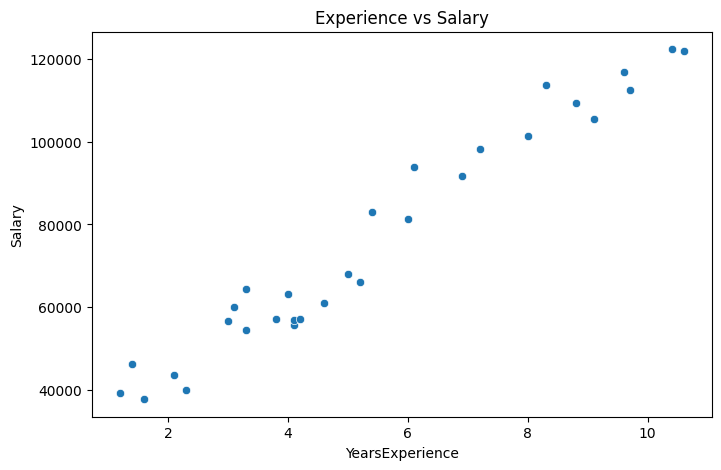

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title("Experience vs Salary")
plt.show()

Strong positive relationship is expected between experience and salary.

In [ ]:
df['Experience_Squared'] = df['YearsExperience'] ** 2
df.head()

,Unnamed: 0,YearsExperience,Salary,Experience_Squared
0,0,1.2,39344.0,1.44
1,1,1.4,46206.0,1.96
2,2,1.6,37732.0,2.56
3,3,2.1,43526.0,4.41
4,4,2.3,39892.0,5.29


We created one extra feature to capture possible non-linear growth.

In [ ]:
X = df[['YearsExperience', 'Experience_Squared']]
y = df['Salary']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 74787.625
Coefficients: [25165.94915474   816.32651236]


In [ ]:
y_pred = model.predict(X_test)
y_pred

array([115030.43028672,  82274.10278095,  73945.79359897,  68415.12076454,
       107491.58982541,  41020.15603522])

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 5675.657917608215
MSE : 45075157.392182074
RMSE: 6713.803496691132
R2 Score: 0.9431985661272329


In [ ]:
result = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

result

,Actual Salary,Predicted Salary
0,116970.0,115030.430287
1,93941.0,82274.102781
2,66030.0,73945.793599
3,61112.0,68415.120765
4,109432.0,107491.589825
5,37732.0,41020.156035


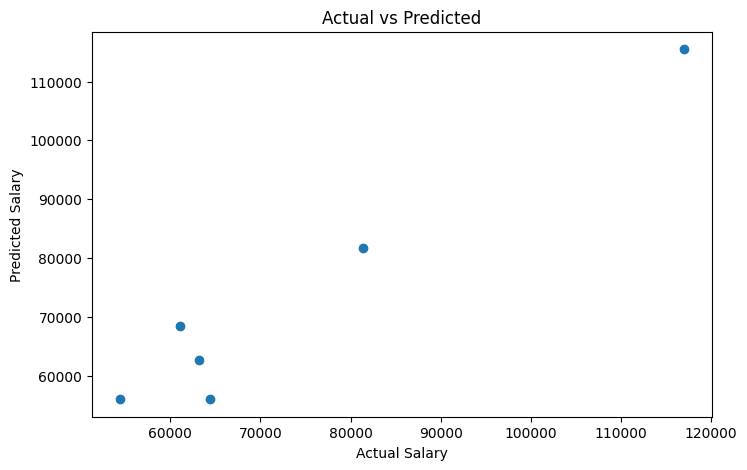

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
new_data = pd.DataFrame({
    'YearsExperience':[2.4],
    'Experience_Squared':[5.76]
})

new_scaled = scaler.transform(new_data)

prediction = model.predict(new_scaled)
print("Predicted Salary:", prediction[0])

Predicted Salary: 48283.370424213266


In [ ]:
# 2. Create Dataset (self-contained)
data = pd.DataFrame({
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
                        3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
                        6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189,
               63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940,
               91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872]
})

## Multiple Linear Regression

Epoch	Train MSE	Test MSE
1	11849425446564939824103424.00		11388075747545116460449792.00
2	15925177495398733236404224.00		14952382855479162470137856.00
3	3406840578550295418634240.00		3177082669421484327305216.00
4	5233842758675684401348608.00		5111067950246870623715328.00
5	3233536438583469031817216.00		3159885077877544416444416.00
6	9236174563198308118953984.00		8681382811823004725542912.00
7	7165951283096382823464960.00		6744211514531958191292416.00
8	5079713977566980118413312.00		4862680897494965454635008.00
9	6016808081650933861187584.00		5706340049763513298583552.00
10	4101234205309745298931712.00		3905519863936903704215552.00
11	3745287607155206186336256.00		3556671847906625412136960.00
12	3662278869968934670434304.00		3440231009583181460406272.00
13	4512105701765311639846912.00		4202932663623271890026496.00
14	1627590951249342837555200.00		1481703732335110816530432.00
15	1839662438066127605071872.00		1674503658865232470605824.00
16	4042878248929575282147328.00		39058680021930002

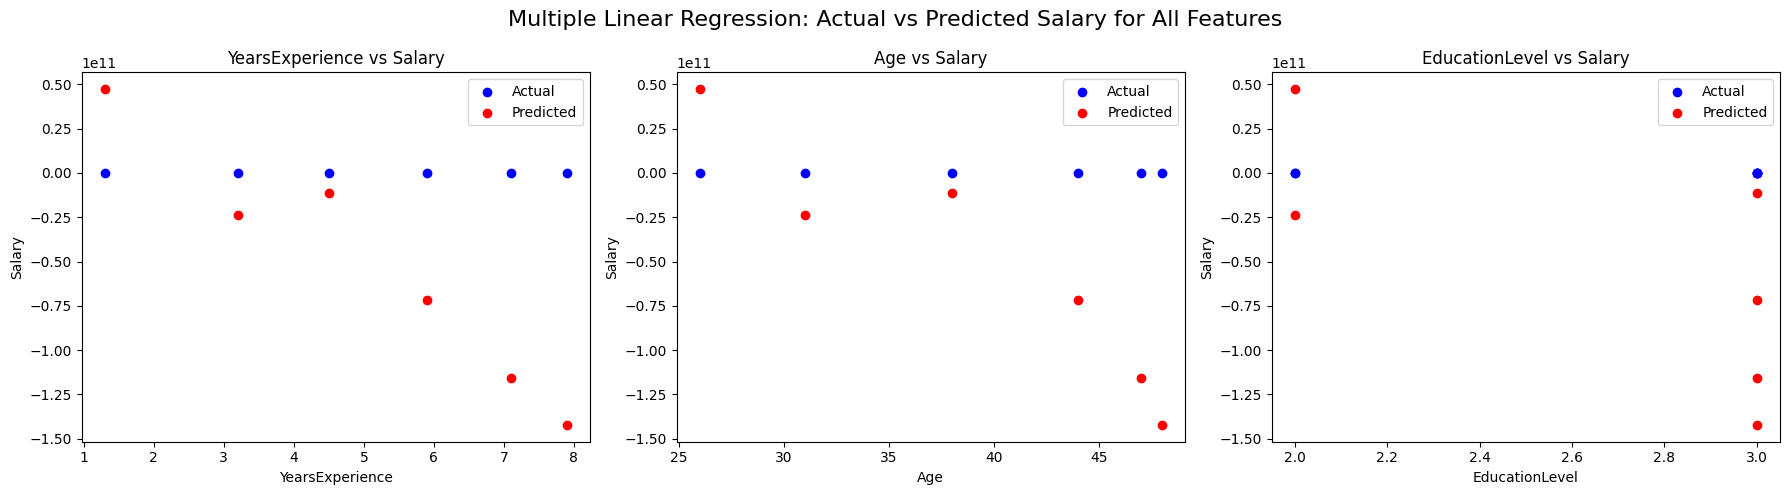

In [ ]:

# Multiple Linear Regression with Epochs: Salary Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 2. Create Self-Contained Dataset
# Features: YearsExperience, Age, EducationLevel
# Target: Salary
data = pd.DataFrame({
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
                        3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
                        6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
    'Age': [25, 26, 24, 28, 27, 30, 32, 31, 33, 34,
            35, 36, 36, 37, 38, 40, 41, 42, 44, 45,
            46, 47, 48, 49, 50, 51, 52, 53, 54, 55],
    'EducationLevel': [1, 2, 1, 2, 2, 3, 3, 2, 2, 3,
                       3, 3, 2, 2, 3, 3, 3, 3, 3, 3,
                       3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189,
               63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940,
               91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872]
})

# 3. Define features (X) and target (y)
X = data[['YearsExperience', 'Age', 'EducationLevel']].values
y = data['Salary'].values

# 4. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# 5. Initialize SGDRegressor for Multiple Linear Regression
sgd_model = SGDRegressor(max_iter=1, tol=None, eta0=0.01, random_state=12)

# 6. Train with explicit epochs
epochs = 100
print("Epoch\tTrain MSE\tTest MSE")
for epoch in range(1, epochs + 1):
    sgd_model.partial_fit(X_train, y_train)  # one pass over training data

    # Predictions
    y_train_pred = sgd_model.predict(X_train)
    y_test_pred = sgd_model.predict(X_test)

    # Compute MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    print(f"{epoch}\t{train_mse:.2f}\t\t{test_mse:.2f}")

# 7. Final model parameters
print("\nFinal Coefficients:", sgd_model.coef_)
print("Final Intercept:", sgd_model.intercept_)

# 8. Visualization: Actual vs Predicted for each feature
features = ['YearsExperience', 'Age', 'EducationLevel']
X_test_df = pd.DataFrame(X_test, columns=features)
y_test_pred = sgd_model.predict(X_test)

plt.figure(figsize=(18, 5))
for i, feature in enumerate(features):
    plt.subplot(1, 3, i + 1)
    plt.scatter(X_test_df[feature], y_test, color='blue', label='Actual')
    plt.scatter(X_test_df[feature], y_test_pred, color='red', label='Predicted')
    plt.xlabel(feature)
    plt.ylabel("Salary")
    plt.title(f"{feature} vs Salary")
    plt.legend()

plt.suptitle("Multiple Linear Regression: Actual vs Predicted Salary for All Features", fontsize=16)
plt.tight_layout()
plt.show()
